In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def display_df(df):
    pd.set_option("display.max_rows", None)     
    pd.set_option("display.max_columns", None) 
    pd.set_option("display.width", None)       

    with pd.option_context("display.max_rows", None):
        display(df)

    pd.reset_option("display.max_rows")
    pd.reset_option("display.max_columns")
    pd.reset_option("display.width")

def randomize_pair(df):
    """
    Randomly swap red (r_*) and blue (b_*) fighter columns for each row to prevent ordering bias.
    For each row, with 50% probability, swaps all r_* and b_* column pairs and flips the winner label.
    
    This ensures the model doesn't learn positional bias (e.g., always predicting red wins).
    """
    df_swapped = df.copy()
    
    # Get all r_* and b_* column pairs
    r_cols = sorted([col for col in df.columns if col.startswith('r_')])
    b_cols = sorted([col for col in df.columns if col.startswith('b_')])
    
    # Create mapping: r_col -> corresponding b_col
    col_pairs = {}
    for r_col in r_cols:
        b_col = r_col.replace('r_', 'b_', 1)
        if b_col in b_cols:
            col_pairs[r_col] = b_col
    
    # Randomly decide which rows to swap (50% chance per row)
    np.random.seed(None)  # Use random seed for each call
    swap_mask = np.random.rand(len(df)) > 0.5
    
    # Swap all column pairs for rows where swap_mask is True
    for r_col, b_col in col_pairs.items():
        # Store values before swapping
        r_values = df_swapped[r_col].values.copy()
        b_values = df_swapped[b_col].values.copy()
        
        # Swap where mask is True
        df_swapped.loc[swap_mask, r_col] = b_values[swap_mask]
        df_swapped.loc[swap_mask, b_col] = r_values[swap_mask]
    
    # Flip winner label: 'r' -> 'b', 'b' -> 'r' for swapped rows
    if 'winner' in df_swapped.columns:
        # Ensure winner is string type
        df_swapped['winner'] = df_swapped['winner'].astype(str).str.strip().str.lower()
        
        # Create a copy for safe swapping
        winner_values = df_swapped['winner'].values.copy()
        
        # Swap winner labels where rows were swapped
        r_wins = (winner_values == 'r') & swap_mask
        b_wins = (winner_values == 'b') & swap_mask
        
        winner_values[r_wins] = 'b'
        winner_values[b_wins] = 'r'
        
        df_swapped['winner'] = winner_values
    
    return df_swapped

In [3]:
data_path = Path("data") / "archive" / "UFC.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path.resolve()}")

columns_to_keep = [
    'r_id',
    'b_id', 
    'r_name',
    'b_name',
    'date',
    'method',
    'r_wins',
    'b_wins',
    'r_losses',
    'b_losses',
    'r_draws',
    'b_draws',
    'b_height',
    'r_height',
    'b_reach',
    'r_reach',
    'b_stance',
    'r_stance',
    'r_weight',
    'b_weight',
    'r_dob',
    'b_dob',
    'r_splm',
    'b_splm',
    'r_td_acc',
    'b_td_acc',    
    'r_str_acc',
    'b_str_acc',
    'r_sapm',
    'b_sapm',
    'r_str_def',
    'b_str_def',
    'r_td_avg',
    'b_td_avg',
    'r_td_avg_acc',
    'b_td_avg_acc',
    'r_td_def',
    'b_td_def',
    'r_sub_avg',
    'b_sub_avg',
    'division',
    'title_fight',
    'winner_id',
]

ufc_df = pd.read_csv(data_path)
ufc_df = ufc_df[columns_to_keep]

display_df(ufc_df.head())


,r_id,b_id,r_name,b_name,date,method,r_wins,b_wins,r_losses,b_losses,r_draws,b_draws,b_height,r_height,b_reach,r_reach,b_stance,r_stance,r_weight,b_weight,r_dob,b_dob,r_splm,b_splm,r_td_acc,b_td_acc,r_str_acc,b_str_acc,r_sapm,b_sapm,r_str_def,b_str_def,r_td_avg,b_td_avg,r_td_avg_acc,b_td_avg_acc,r_td_def,b_td_def,r_sub_avg,b_sub_avg,division,title_fight,winner_id
0,c2299ec916bc7c56,9c393e836a852f30,Benoit Saint Denis,Mauricio Ruffy,2025/09/06,Submission,15,12,3,2,0,0,180.34,180.34,190.50,185.42,Orthodox,Southpaw,70.31,70.31,1995/12/18,1996/06/17,5.05,3.84,30.0,NaN,55,57,4.19,4.16,42,60,4.35,0.00,37,0,70,84,1.6,0.0,lightweight,0,c2299ec916bc7c56
1,881bf86d4cba8578,4126a78111c0855a,Nassourdine Imavov,Caio Borralho,2025/09/06,Decision - Unanimous,17,17,4,2,0,0,185.42,190.50,190.50,190.50,Southpaw,Orthodox,83.91,83.91,1996/03/01,1993/01/16,4.28,3.44,NaN,0.0,54,56,3.17,2.50,58,60,0.74,1.28,32,48,81,76,1.0,0.4,middleweight,0,881bf86d4cba8578
2,476fe566d2df676e,eabf206b162b3b83,Modestas Bukauskas,Paul Craig,2025/09/06,KO/TKO,19,17,6,10,0,1,190.50,190.50,193.04,193.04,Orthodox,Switch,92.99,92.99,1994/02/10,1987/11/27,3.32,2.50,NaN,0.0,43,45,3.93,3.04,51,43,0.30,1.43,66,18,80,35,0.1,1.3,light heavyweight,0,476fe566d2df676e
3,4bdedbdeedff7d1d,f6ad6a1e4d600e0d,Bolaji Oki,Mason Jones,2025/09/06,KO/TKO,10,17,3,2,0,0,177.80,177.80,187.96,185.42,Orthodox,Orthodox,70.31,70.31,1995/11/15,1995/04/26,6.59,5.71,0.0,100.0,44,41,5.15,4.47,61,50,1.01,4.17,60,55,66,81,0.0,0.2,lightweight,0,f6ad6a1e4d600e0d
4,1d2d98ddd05b38fb,f748267c4ab6c127,Axel Sola,Rhys McKee,2025/09/06,KO/TKO,11,14,0,7,1,1,187.96,187.96,198.12,187.96,Orthodox,Southpaw,77.11,77.11,1997/09/17,1995/09/10,3.74,4.71,25.0,NaN,42,40,2.74,7.15,75,47,1.25,0.00,25,0,0,47,0.0,0.0,welterweight,0,1d2d98ddd05b38fb


In [4]:
desc_df = ufc_df.describe().T
desc_df["na_count"] = ufc_df.isna().sum()
display_df(desc_df)

,count,mean,std,min,25%,50%,75%,max,na_count
r_wins,8337.0,19.233297,9.264114,0.00,13.00,18.00,24.00,253.00,0
b_wins,8337.0,17.272160,9.016829,0.00,11.00,16.00,22.00,253.00,0
r_losses,8337.0,8.056735,4.691696,0.00,5.00,7.00,11.00,53.00,0
b_losses,8337.0,7.504138,4.492130,0.00,4.00,7.00,10.00,53.00,0
r_draws,8337.0,0.241214,0.604279,0.00,0.00,0.00,0.00,10.00,0
b_draws,8337.0,0.252849,0.696767,0.00,0.00,0.00,0.00,11.00,0
b_height,8316.0,178.460962,8.984635,152.40,172.72,177.80,185.42,210.82,21
r_height,8332.0,178.534076,9.044297,152.40,172.72,177.80,185.42,210.82,5
b_reach,7436.0,182.684615,10.791596,147.32,175.26,182.88,190.50,213.36,901
r_reach,7917.0,183.104580,10.949027,147.32,175.26,182.88,190.50,213.36,420


,feature,unique_categories
0,b_id,2450
1,b_name,2449
2,b_dob,2038
3,r_id,1924
4,r_name,1923
5,winner_id,1829
6,r_dob,1679
7,date,740
8,division,107
9,method,10


/var/folders/yj/3yq26dgs2nn76q3v6zwh32mc0000gn/T/ipykernel_23418/3908359429.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


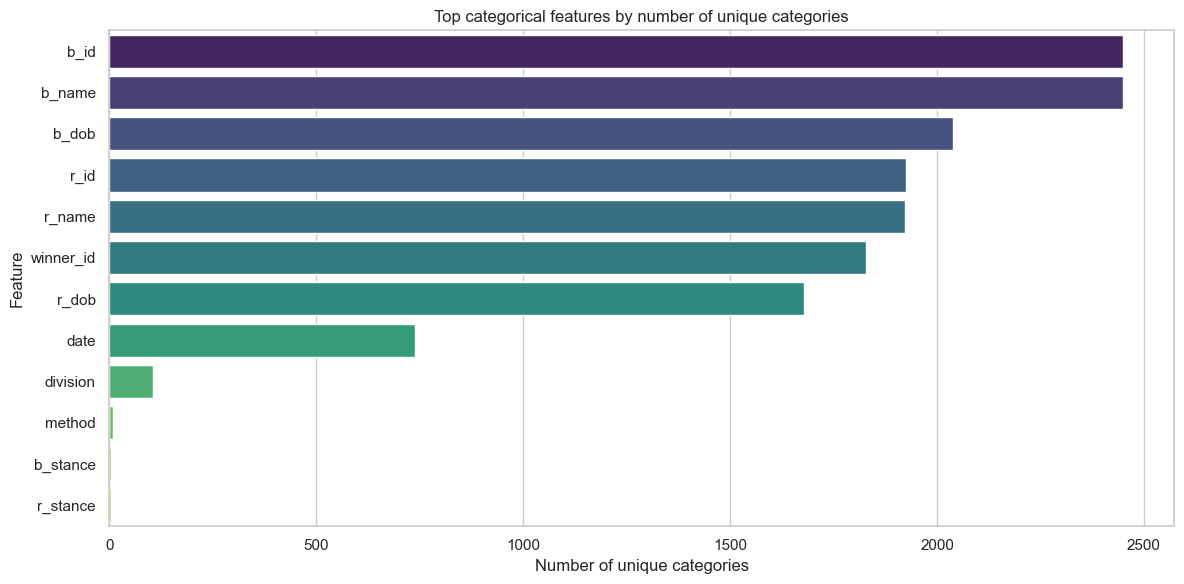

In [5]:
# Analyze categorical columns: number of distinct categories per feature
categorical_cols = ufc_df.select_dtypes(include=["object", "category"]).columns

cat_summary = (
    ufc_df[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "unique_categories"})
)

display(cat_summary)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=cat_summary.head(20),
    x="unique_categories",
    y="feature",
    palette="viridis"
)
plt.title("Top categorical features by number of unique categories")
plt.xlabel("Number of unique categories")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Feature Engineering

**Assumptions:** We will assume fights are the same across time for simplicity, so we will not consider the dates of fights. 

*Transformations*
- `r_dob` and `b_dob` (Date of Birth) to numerical `r_age` and `b_age` since age is likely an important feature
- `winner_id` to binary feature `winner` which will also be target label and drop `b_id` and `r_id`
- We will also only use the fighter's win-loss ratio. 
- I will only consider Orthodox and Southpaw and convert all other categories to orthodox since these are the common stances. 
- We will simplify further to drop `r_stance` and `b_stance` and make new feature `open_stance` for whether the fighters are in opposite stances or not.

In [6]:
def get_specific_fighter_momentum(df, fighter_name, cutoff_date):
    """
    Compute the number of wins in a fighter's last 3 fights before a cutoff date.
    
    Returns:
    - Number of wins in last 3 fights (0-3), or None if fighter has less than 3 fights
    """
    # Filter fights before cutoff date
    df_filtered = df[df['date'] < cutoff_date]
    
    # Get all fights for this fighter (both as red and blue fighter)
    fighter_fights = df_filtered[
        (df_filtered['r_name'] == fighter_name) | 
        (df_filtered['b_name'] == fighter_name)
    ].copy()
    
    # Sort by date to get chronological order (most recent first)
    fighter_fights = fighter_fights.sort_values('date', ascending=False)
    
    # Check if fighter has at least 3 fights
    if len(fighter_fights) < 3:
        return None
    
    # Get last 3 fights
    last_3_fights = fighter_fights.head(3)
    
    # Count wins in last 3 fights
    wins_in_last_3 = 0
    for _, fight in last_3_fights.iterrows():
        # Check if fighter won (either as red or blue fighter)
        if fight['r_name'] == fighter_name and fight['winner'] == 'Red':
            wins_in_last_3 += 1
        elif fight['b_name'] == fighter_name and fight['winner'] == 'Blue':
            wins_in_last_3 += 1
    
    return wins_in_last_3


In [7]:
def get_specific_fighter_kos(df, fighter_name, cutoff_date):
    """
    Get KO count for a specific fighter before a date
    """
    # Filter fights before cutoff date
    df_filtered = df[df['date'] < cutoff_date]
    
    # Count KO wins where fighter won by KO/TKO
    red_ko_wins = len(df_filtered[
        (df_filtered['r_name'] == fighter_name) & 
        (df_filtered['winner'] == 'Red') & 
        ('TKO' in df_filtered['method'])
    ])
    
    blue_ko_wins = len(df_filtered[
        (df_filtered['b_name'] == fighter_name) & 
        (df_filtered['winner'] == 'Blue') & 
        (df_filtered['method'] == 'KO/TKO')
    ])

    red_total_fights = len(df_filtered[df_filtered['r_name'] == fighter_name])
    blue_total_fights = len(df_filtered[df_filtered['b_name'] == fighter_name])
    
    total_ko_wins = red_ko_wins + blue_ko_wins
    if (red_total_fights + blue_total_fights) == 0:
        return 0
    else:
        return total_ko_wins / (red_total_fights + blue_total_fights)

def get_specific_fighter_subs(df, fighter_name, cutoff_date):
    """
    Get Submission count for a specific fighter before a date
    """
    # Filter fights before cutoff date  
    df_filtered = df[df['date'] < cutoff_date]
    
    # Count Submission wins where fighter won by Submission
    red_sub_wins = len(df_filtered[
        (df_filtered['r_name'] == fighter_name) & 
        (df_filtered['winner'] == 'Red') & 
        ('Submission' in df_filtered['method'])
    ])
    
    blue_sub_wins = len(df_filtered[
        (df_filtered['b_name'] == fighter_name) & 
        (df_filtered['winner'] == 'Blue') & 
        ('Submission' in df_filtered['method'])
    ])

    red_total_fights = len(df_filtered[df_filtered['r_name'] == fighter_name])
    blue_total_fights = len(df_filtered[df_filtered['b_name'] == fighter_name])
    
    total_sub_wins = red_sub_wins + blue_sub_wins
    
    if (red_total_fights + blue_total_fights) == 0:
        return 0
    else:
        return total_sub_wins / (red_total_fights + blue_total_fights)


    


In [8]:
# Parse date of birth strings (handles formats like "May 08, 1982" or "1995/12/18")
ufc_df['r_dob'] = pd.to_datetime(ufc_df['r_dob'], errors='coerce')
ufc_df['b_dob'] = pd.to_datetime(ufc_df['b_dob'], errors='coerce')

# Create winner column: 'r' if winner_id matches r_id, 'b' if it matches b_id
ufc_df['winner'] = ufc_df['winner_id'] == ufc_df['r_id']

# Calculate age at today's date (accurate age calculation)
today = pd.Timestamp.today()
ufc_df['r_age'] = ((today - ufc_df['r_dob']).dt.days / 365.25).round(2)
ufc_df['b_age'] = ((today - ufc_df['b_dob']).dt.days / 365.25).round(2)

ufc_df['r_win_loss_ratio'] = ufc_df['r_wins'] / (ufc_df['r_wins'] + ufc_df['r_losses'])
ufc_df['b_win_loss_ratio'] = ufc_df['b_wins'] / (ufc_df['b_wins'] + ufc_df['b_losses'])

# Normalize stance values: keep only 'Orthodox' and 'Southpaw', map everything else to 'Orthodox'
valid_stances = {"Orthodox", "Southpaw"}
ufc_df['r_stance'] = ufc_df['r_stance'].where(ufc_df['r_stance'].isin(valid_stances), 'Orthodox')
ufc_df['b_stance'] = ufc_df['b_stance'].where(ufc_df['b_stance'].isin(valid_stances), 'Orthodox')

for index, row in ufc_df.iterrows():
    if (index % 1000 == 0): print(f"Processing row {index} of {len(ufc_df)}")
    # ufc_df.loc[index, 'r_sub_rate'] = get_specific_fighter_subs(ufc_df, row['r_name'], row['date'])
    # ufc_df.loc[index, 'b_sub_rate'] = get_specific_fighter_subs(ufc_df, row['b_name'], row['date'])
    ufc_df.loc[index, 'r_ko_rate'] = get_specific_fighter_kos(ufc_df, row['r_name'], row['date'])
    ufc_df.loc[index, 'b_ko_rate'] = get_specific_fighter_kos(ufc_df, row['b_name'], row['date'])
    # ufc_df.loc[index, 'r_momentum'] = get_specific_fighter_momentum(ufc_df, row['r_name'], row['date'])
    # ufc_df.loc[index, 'b_momentum'] = get_specific_fighter_momentum(ufc_df, row['b_name'], row['date'])

# Drop columns no longer needed
ufc_df = ufc_df.drop(columns=['winner_id', 'division', 'r_dob', 'b_dob', 'r_id', 'b_id', 'r_wins', 'r_losses', 'b_wins', 'b_losses', 'r_draws', 'b_draws', 'r_name', 'b_name', 'date', 'method'])
display_df(ufc_df.head())

Processing row 0 of 8337
Processing row 1000 of 8337
Processing row 2000 of 8337
Processing row 3000 of 8337
Processing row 4000 of 8337
Processing row 5000 of 8337
Processing row 6000 of 8337
Processing row 7000 of 8337
Processing row 8000 of 8337


,b_height,r_height,b_reach,r_reach,b_stance,r_stance,r_weight,b_weight,r_splm,b_splm,r_td_acc,b_td_acc,r_str_acc,b_str_acc,r_sapm,b_sapm,r_str_def,b_str_def,r_td_avg,b_td_avg,r_td_avg_acc,b_td_avg_acc,r_td_def,b_td_def,r_sub_avg,b_sub_avg,title_fight,winner,r_age,b_age,r_win_loss_ratio,b_win_loss_ratio,r_ko_rate,b_ko_rate
0,180.34,180.34,190.50,185.42,Orthodox,Southpaw,70.31,70.31,5.05,3.84,30.0,NaN,55,57,4.19,4.16,42,60,4.35,0.00,37,0,70,84,1.6,0.0,0,True,29.97,29.47,0.833333,0.857143,0.0,0.0
1,185.42,190.50,190.50,190.50,Southpaw,Orthodox,83.91,83.91,4.28,3.44,NaN,0.0,54,56,3.17,2.50,58,60,0.74,1.28,32,48,81,76,1.0,0.4,0,True,29.77,32.89,0.809524,0.894737,0.0,0.0
2,190.50,190.50,193.04,193.04,Orthodox,Orthodox,92.99,92.99,3.32,2.50,NaN,0.0,43,45,3.93,3.04,51,43,0.30,1.43,66,18,80,35,0.1,1.3,0,True,31.82,38.03,0.760000,0.629630,0.0,0.0
3,177.80,177.80,187.96,185.42,Orthodox,Orthodox,70.31,70.31,6.59,5.71,0.0,100.0,44,41,5.15,4.47,61,50,1.01,4.17,60,55,66,81,0.0,0.2,0,False,30.06,30.61,0.769231,0.894737,0.0,0.0
4,187.96,187.96,198.12,187.96,Orthodox,Southpaw,77.11,77.11,3.74,4.71,25.0,NaN,42,40,2.74,7.15,75,47,1.25,0.00,25,0,0,47,0.0,0.0,0,True,28.22,30.24,1.000000,0.666667,0.0,0.0


In [9]:
X = ufc_df.drop(columns=['winner'])
y = ufc_df['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

In [10]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

categorical_features = ['title_fight', 'r_stance', 'b_stance']
numerical_features = [col for col in X_train.columns if col not in categorical_features]

# Handle missing values and convert to proper types within transformers
numerical_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

# For categorical: fill missing with most frequent, then one-hot encode
categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = Pipeline([
    ('transform', ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features),
        ],
        remainder='drop'
    ))
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

(6669, 36) (1668, 36)


In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(max_iter=500, random_state=42, activation='relu', solver='adam', learning_rate='adaptive'))
])

param_grid = {
    'clf__hidden_layer_sizes': [(16, 8, 4, 2), (16, 8, 8, 4, 2), (16, 8, 4, 3, 2)],
    'clf__alpha': [1e-3, 1e-2, 1e-1, 1, 10],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print("Best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_
cv_scores = cross_val_score(best_model, X_train, y_train, cv=10, scoring='accuracy')
print("Cross-validation accuracy scores:", cv_scores)
print("Mean cross-validation accuracy:", cv_scores.mean())

best_model.fit(X_train, y_train)


Fitting 10 folds for each of 15 candidates, totalling 150 fits
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.7s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.9s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.0s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.0s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.3s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   3.3s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   4.4s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   4.4s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 4, 2); total time=   2.2s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 8, 4, 2); total time=   2.2s
[CV] END clf__alpha=0.001, clf__hidden_layer_sizes=(16, 8, 8, 4, 2); total time=   2

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('transform', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [12]:
# LightGBM Model: 1000 rounds, lr=0.03, early_stopping=50
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Preprocess and prepare data
X_train_processed = preprocessor.fit_transform(X_train)
y_train_binary = y_train.astype(int) if y_train.dtype == bool else (y_train == 'r').astype(int)

# Split for validation
X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(
    X_train_processed, y_train_binary, test_size=0.2, random_state=42, stratify=y_train_binary
)

# Train with early stopping
params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.03,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

lgb_model_val = lgb.train(
    params,
    lgb.Dataset(X_train_lgb, label=y_train_lgb),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(X_train_lgb, label=y_train_lgb), lgb.Dataset(X_val_lgb, label=y_val_lgb)],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True), lgb.log_evaluation(period=50)]
)

# Get validation results
best_iter = lgb_model_val.best_iteration
valid_metrics = lgb_model_val.best_score['valid']
train_metrics = lgb_model_val.best_score['train']
metric_key = 'binary_error' if 'binary_error' in valid_metrics else list(valid_metrics.keys())[0]

validation_error = valid_metrics[metric_key]
train_error = train_metrics.get(metric_key)

if metric_key == 'binary_error':
    print(f"\nBest iteration: {best_iter}")
    print(f"Train accuracy: {(1 - train_error) * 100:.2f}%")
    print(f"Validation accuracy: {(1 - validation_error) * 100:.2f}%")
else:
    print(f"\nBest iteration: {best_iter}")
    print(f"Validation {metric_key}: {validation_error:.6f}")

# Retrain on full training set
lgb_model = lgb.train(
    params,
    lgb.Dataset(X_train_processed, label=y_train_binary),
    num_boost_round=best_iter,
    callbacks=[lgb.log_evaluation(period=50)]
)


Training until validation scores don't improve for 50 rounds
[50]	train's binary_error: 0.197188	valid's binary_error: 0.278861
[100]	train's binary_error: 0.158575	valid's binary_error: 0.263868
[150]	train's binary_error: 0.132521	valid's binary_error: 0.257121
[200]	train's binary_error: 0.107216	valid's binary_error: 0.261619
Early stopping, best iteration is:
[154]	train's binary_error: 0.129522	valid's binary_error: 0.253373

Best iteration: 154
Train accuracy: 87.05%
Validation accuracy: 74.66%


In [13]:
# Regularized Logistic Regression with GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Create pipeline with preprocessor and logistic regression
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Define parameter grid for hyperparameter tuning
# Note: liblinear supports both L1 and L2, lbfgs only supports L2
param_grid = [
    {
        'clf__penalty': ['l1'],
        'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'clf__solver': ['liblinear']
    },
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'clf__solver': ['liblinear', 'lbfgs']
    }
]

# Perform grid search with 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Get best parameters and best CV score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Train final model on full training set with best parameters
logistic_model = grid_search.best_estimator_
print(f"\nModel trained on full training set with best parameters")

Fitting 10 folds for each of 18 candidates, totalling 180 fits
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.1s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.1s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.1s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.001, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.01, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.01, clf__penalty=l1, clf__solver=liblinear; total time=   0.0s
[CV] END clf__C=0.01, clf__penalty=l1

In [14]:
# SVM with RBF Kernel and GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Create pipeline with preprocessor and SVM
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(kernel='rbf', random_state=42, probability=True))
])

# Define parameter grid for hyperparameter tuning
# param_grid = {
#     'clf__C': [0.1, 1.0, 10.0, 100.0, 1000.0],
#     'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
# }
param_grid = {
    'clf__C': [10.0],
    'clf__gamma': [ 0.01]
}

# Perform grid search with 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Get best parameters and best CV score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Train final model on full training set with best parameters
svm_model = grid_search.best_estimator_
print(f"\nModel trained on full training set with best parameters")


Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.7s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.7s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.7s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.9s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.9s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.9s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.9s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   4.9s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   2.8s
[CV] END .......................clf__C=10.0, clf__gamma=0.01; total time=   2.9s

Best parameters: {'clf__C': 10.0, 'clf__gamma': 0.01}
Best cross-validation accuracy: 0.7524

Model trained on full training set

Best parameters: `{'clf__C': 10.0, 'clf__gamma': 0.01}`

In [15]:
# Random Forest with GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Create pipeline with preprocessor and Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# # Define parameter grid for hyperparameter tuning
# param_grid = {
#     'clf__n_estimators': [50, 100, 200, 300],
#     'clf__max_depth': [10, 20, 30, None],
#     'clf__min_samples_split': [2, 5, 10],
#     'clf__min_samples_leaf': [1, 2, 4]
# }

# Define parameter grid for hyperparameter tuning
param_grid = {
    'clf__n_estimators': [ 300],
    'clf__max_depth': [20],
    'clf__min_samples_split': [2],
    'clf__min_samples_leaf': [2]
}


# Perform grid search with 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Get best parameters and best CV score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Train final model on full training set with best parameters
rf_model = grid_search.best_estimator_
print(f"\nModel trained on full training set with best parameters")


Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.4s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.5s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.6s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.5s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.5s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.6s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=300; total time=   3.6s
[CV] END clf__max_depth=20, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estima

Best parameters: `{'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}`

In [16]:
# Stacking Classifier with all models
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import numpy as np

# Create base estimators for stacking
# Note: StackingClassifier will retrain these models, so we provide the estimator definitions

# 1. MLP Classifier (use best params from grid search)
mlp_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(alpha=1, hidden_layer_sizes=(16, 8, 4, 2), max_iter=500, 
                          random_state=42, activation='relu', solver='adam', learning_rate='adaptive'))
])

# 2. LightGBM (use sklearn-compatible LGBMClassifier with same params as trained model)
lgb_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LGBMClassifier(
        objective='binary',
        metric='binary_error',
        boosting_type='gbdt',
        num_leaves=31,
        learning_rate=0.03,
        feature_fraction=0.9,
        bagging_fraction=0.8,
        bagging_freq=5,
        n_estimators=1000,  # Will use early stopping in CV
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

# 3. Logistic Regression (use best params from grid search - will be determined during stacking)
logistic_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 4. SVM (use best params from grid search - will be determined during stacking)
svm_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(kernel='rbf', random_state=42, probability=True))
])

# 5. Random Forest (use best params from grid search - will be determined during stacking)
rf_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define base estimators for stacking
base_estimators = [
    ('mlp', mlp_estimator),
    ('lgbm', lgb_estimator),
    ('logistic', logistic_estimator),
    ('svm', svm_estimator),
    ('rf', rf_estimator)
]

# Create stacking classifier with logistic regression as meta-learner
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=10,
    n_jobs=-1,
    verbose=1
)

# Perform cross-validation to evaluate stacking classifier
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(stacking_clf, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Stacking Classifier Cross-Validation Results:")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Individual fold accuracies: {cv_scores}")

# Train final stacking model on full training set
stacking_model = stacking_clf.fit(X_train, y_train)
print(f"\nStacking model trained on full training set")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    4.6s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   11.8s remaining:    7.8s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   13.0s remaining:    8.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   15.4s finished
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   25

Stacking Classifier Cross-Validation Results:
Mean CV Accuracy: 0.7566 (+/- 0.0157)
Individual fold accuracies: [0.76311844 0.75112444 0.75412294 0.75412294 0.75862069 0.74062969
 0.78410795 0.77811094 0.75562219 0.72672673]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    6.7s remaining:    4.5s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   10.4s finished
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   13.1s remaining:    8.7s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   18.4s finished
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   19.9s remaining:   13.3s
/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/l


Stacking model trained on full training set


/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   42.0s finished


In [17]:
# Evaluate Stacking Classifier on Test Set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on test set
y_test_pred = stacking_model.predict(X_test)
y_test_pred_proba = stacking_model.predict_proba(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Stacking Classifier Test Set Results:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_test_pred)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_test_pred)}")

/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Classifier Test Set Results:
Test Accuracy: 0.7524

Classification Report:
              precision    recall  f1-score   support

       False       0.70      0.53      0.60       596
        True       0.77      0.88      0.82      1072

    accuracy                           0.75      1668
   macro avg       0.74      0.70      0.71      1668
weighted avg       0.75      0.75      0.74      1668


Confusion Matrix:
[[315 281]
 [132 940]]


In [18]:
# ============================================================================
# RETRAIN ALL MODELS ON FULL DATASET FOR DEPLOYMENT
# ============================================================================
# This cell retrains all models on the complete dataset (X, y) instead of 
# just the training set, then saves all models for deployment.
# ============================================================================

from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import lightgbm as lgb
import numpy as np

print("=" * 80)
print("RETRAINING ALL MODELS ON FULL DATASET FOR DEPLOYMENT")
print("=" * 80)
print(f"Full dataset size: {len(X)} samples")
print()

# First, retrain individual models on full dataset with best parameters

# 1. MLP Classifier - Retrain on full dataset
print("1. Training MLP Classifier on full dataset...")
mlp_full = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(alpha=1, hidden_layer_sizes=(16, 8, 4, 2), max_iter=500, 
                          random_state=42, activation='relu', solver='adam', learning_rate='adaptive'))
])
mlp_full.fit(X, y)
print("   ✓ MLP Classifier trained")

# 2. LightGBM - Retrain on full dataset
print("2. Training LightGBM on full dataset...")
X_processed_full = preprocessor.fit_transform(X)
y_binary_full = y.astype(int) if y.dtype == bool else (y == 'r').astype(int)

# Split for early stopping (20% validation)
X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(
    X_processed_full, y_binary_full, test_size=0.2, random_state=42, stratify=y_binary_full
)

params_lgb = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.03,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

lgb_full_val = lgb.train(
    params_lgb,
    lgb.Dataset(X_train_lgb, label=y_train_lgb),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(X_train_lgb, label=y_train_lgb), lgb.Dataset(X_val_lgb, label=y_val_lgb)],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)]
)

best_iter_lgb = lgb_full_val.best_iteration
lgb_full = lgb.train(
    params_lgb,
    lgb.Dataset(X_processed_full, label=y_binary_full),
    num_boost_round=best_iter_lgb,
    callbacks=[lgb.log_evaluation(period=0)]
)
print(f"   ✓ LightGBM trained (best_iter={best_iter_lgb})")

# 3. Logistic Regression - Retrain on full dataset
print("3. Training Logistic Regression on full dataset...")
logistic_full = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42))
])
logistic_full.fit(X, y)
print("   ✓ Logistic Regression trained")

# 4. SVM - Retrain on full dataset
print("4. Training SVM on full dataset...")
svm_full = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(kernel='rbf', C=10.0, gamma=0.01, random_state=42, probability=True))
])
svm_full.fit(X, y)
print("   ✓ SVM trained")

# 5. Random Forest - Retrain on full dataset
print("5. Training Random Forest on full dataset...")
rf_full = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, 
                                   min_samples_leaf=2, random_state=42, n_jobs=-1))
])
rf_full.fit(X, y)
print("   ✓ Random Forest trained")

# Now create stacking classifier with all models trained on full dataset
print("\n6. Creating and training Stacking Classifier on full dataset...")

# Create base estimators for stacking (these will be retrained during stacking CV)
mlp_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', MLPClassifier(alpha=1, hidden_layer_sizes=(16, 8, 4, 2), max_iter=500, 
                          random_state=42, activation='relu', solver='adam', learning_rate='adaptive'))
])

lgb_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LGBMClassifier(
        objective='binary',
        num_leaves=31,
        learning_rate=0.03,
        feature_fraction=0.9,
        bagging_fraction=0.8,
        bagging_freq=5,
        n_estimators=best_iter_lgb,  # Use best iteration from validation
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

logistic_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42))
])

svm_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(kernel='rbf', C=10.0, gamma=0.01, random_state=42, probability=True))
])

rf_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, 
                                   min_samples_leaf=2, random_state=42, n_jobs=-1))
])

base_estimators = [
    ('mlp', mlp_estimator),
    ('lgbm', lgb_estimator),
    ('logistic', logistic_estimator),
    ('svm', svm_estimator),
    ('rf', rf_estimator)
]

# Create stacking classifier - will retrain all base models on full dataset
stacking_clf_full = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=10,
    n_jobs=-1,
    verbose=1
)

# Train stacking classifier on FULL dataset
stacking_model_full = stacking_clf_full.fit(X, y)
print("   ✓ Stacking Classifier trained on full dataset")

print("\n" + "=" * 80)
print("ALL MODELS SUCCESSFULLY RETRAINED ON FULL DATASET")
print("=" * 80)
print("\nAll models have been retrained on the complete dataset (X, y):")
print("  - mlp_full: MLP Classifier")
print("  - lgb_full: LightGBM model")
print("  - logistic_full: Logistic Regression")
print("  - svm_full: SVM model")
print("  - rf_full: Random Forest")
print("  - stacking_model_full: Stacking Classifier")
print("\nReady for evaluation and deployment!")


RETRAINING ALL MODELS ON FULL DATASET FOR DEPLOYMENT
Full dataset size: 8337 samples

1. Training MLP Classifier on full dataset...
   ✓ MLP Classifier trained
2. Training LightGBM on full dataset...
   ✓ LightGBM trained (best_iter=136)
3. Training Logistic Regression on full dataset...
   ✓ Logistic Regression trained
4. Training SVM on full dataset...
   ✓ SVM trained
5. Training Random Forest on full dataset...
   ✓ Random Forest trained

6. Creating and training Stacking Classifier on full dataset...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.5s finished
/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with fe

   ✓ Stacking Classifier trained on full dataset

ALL MODELS SUCCESSFULLY RETRAINED ON FULL DATASET

All models have been retrained on the complete dataset (X, y):
  - mlp_full: MLP Classifier
  - lgb_full: LightGBM model
  - logistic_full: Logistic Regression
  - svm_full: SVM model
  - rf_full: Random Forest
  - stacking_model_full: Stacking Classifier

Ready for evaluation and deployment!


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   40.3s finished


In [19]:
# Save all models for deployment
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

print("=" * 80)
print("SAVING ALL MODELS FOR DEPLOYMENT")
print("=" * 80)

# Save preprocessor
print("Saving preprocessor...")
joblib.dump(preprocessor, 'models/preprocessor.joblib')
print("  ✓ Preprocessor saved to models/preprocessor.joblib")

# Save MLP model
print("Saving MLP Classifier...")
joblib.dump(mlp_full, 'models/mlp_model.joblib')
print("  ✓ MLP Classifier saved to models/mlp_model.joblib")

# Save LightGBM model (using native LightGBM format)
print("Saving LightGBM model...")
lgb_full.save_model('models/lgb_model.txt')
print("  ✓ LightGBM model saved to models/lgb_model.txt")

# Save Logistic Regression model
print("Saving Logistic Regression model...")
joblib.dump(logistic_full, 'models/logistic_model.joblib')
print("  ✓ Logistic Regression saved to models/logistic_model.joblib")

# Save SVM model
print("Saving SVM model...")
joblib.dump(svm_full, 'models/svm_model.joblib')
print("  ✓ SVM model saved to models/svm_model.joblib")

# Save Random Forest model
print("Saving Random Forest model...")
joblib.dump(rf_full, 'models/rf_model.joblib')
print("  ✓ Random Forest saved to models/rf_model.joblib")

# Save Stacking Classifier model
print("Saving Stacking Classifier model...")
joblib.dump(stacking_model_full, 'models/stacking_model.joblib')
print("  ✓ Stacking Classifier saved to models/stacking_model.joblib")

print("=" * 80)
print("All models saved successfully!")
print("=" * 80)


SAVING ALL MODELS FOR DEPLOYMENT
Saving preprocessor...
  ✓ Preprocessor saved to models/preprocessor.joblib
Saving MLP Classifier...
  ✓ MLP Classifier saved to models/mlp_model.joblib
Saving LightGBM model...
  ✓ LightGBM model saved to models/lgb_model.txt
Saving Logistic Regression model...
  ✓ Logistic Regression saved to models/logistic_model.joblib
Saving SVM model...
  ✓ SVM model saved to models/svm_model.joblib
Saving Random Forest model...
  ✓ Random Forest saved to models/rf_model.joblib
Saving Stacking Classifier model...
  ✓ Stacking Classifier saved to models/stacking_model.joblib
All models saved successfully!


In [1]:
import pandas as pd
from predict_event_fights import predict_event_fights

# Load and predict
event_file = "events/UFC_Fight_Night__Emmett_vs._Vallejos.json"
df, predictions, probabilities = predict_event_fights(event_file)

# Create probability table
prob_table = pd.DataFrame({
    'Fighter 1': df['r_name'].values,
    'Fighter 2': df['b_name'].values,
    'F1 Win %': [f"{p*100:.1f}%" for p in probabilities[:, 1]],
    'F2 Win %': [f"{p*100:.1f}%" for p in probabilities[:, 0]],
    'Winner': df['predicted_winner_name'].values
})

prob_table

TRANSFORMING EVENT DATA
Loading event from: events/UFC_Fight_Night__Emmett_vs._Vallejos.json
    b_height  r_height  b_reach  r_reach  r_weight  b_weight  r_splm  b_splm  \
0         66        67     70.0     68.0     145.0     145.0    6.12    3.67   
1         64        65     65.0     63.0     115.0     115.0    2.71    2.75   
2         71        71     74.0     74.0     145.0     145.0    7.48    3.88   
3         68        68     71.0     72.0     145.0     145.0    7.73    5.47   
4         76        73     83.0     75.0     205.0     205.0    4.23    3.41   
5         64        69     65.0     70.0     125.0     125.0    4.77    3.95   
6         70        70     75.0     74.0     170.0     170.0    2.78    5.52   
7         77        74     78.0     77.0     225.0     260.0    3.24   10.05   
8         66        69     65.0     71.0     135.0     135.0    4.18    2.15   
9         70        69     73.0     70.0     155.0     155.0    4.15    6.42   
10        73        73     

/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kshoker/Desktop/projects/MMA-Fight-Predictor/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Fighter 1,Fighter 2,F1 Win %,F2 Win %,Winner
0,Kevin Vallejos,Josh Emmett,76.0%,24.0%,Kevin Vallejos
1,Gillian Robertson,Amanda Lemos,49.9%,50.1%,Amanda Lemos
2,Jose Delgado,Andre Fili,60.1%,39.9%,Jose Delgado
3,Marwan Rahiki,Harry Hardwick,79.1%,20.9%,Marwan Rahiki
4,Ion Cutelaba,Oumar Sy,28.3%,71.7%,Oumar Sy
5,Charles Johnson,Bruno Silva,51.8%,48.2%,Charles Johnson
6,Myktybek Orolbai,Chris Curtis,86.9%,13.1%,Myktybek Orolbai
7,Vitor Petrino,Steven Asplund,68.1%,31.9%,Vitor Petrino
8,Elijah Smith,SuYoung You,68.9%,31.1%,Elijah Smith
9,Manoel Sousa,Bolaji Oki,74.2%,25.8%,Manoel Sousa
